In [6]:
import ctypes as ct
import MDAnalysis as mda
import MDA_unwrap_PBC as pbc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import trvdos as vd
import pickle

In [7]:
TOPOL = "/nfs/homes3/lrepa/Projects/Summer26_streaming/trvdos/trvdos/tests/inputs/run-NVE.tpr"
TRAJ = "/nfs/homes3/lrepa/Projects/Summer26_streaming/trvdos/trvdos/tests/inputs/run-NVE_trunc.trr"
u = mda.Universe(TOPOL,TRAJ)
sel = u.select_atoms("resname POPC")
vdos = vd.vdos(sel,10)
print(vdos)

In [8]:
vd.vdosLib.omp_set_num_threads(4)
tStep = 0
for ts in tqdm(u.trajectory):
    vdos.single_frame(tStep,ts.time)
    tStep += 1

100%|██████████| 32/32 [00:00<00:00, 103.33it/s]


In [ ]:
# we post-process a copy of our data allowing us to keep accumulating data
vdos.copyResidueList()
vdos.postProcess(vdos.residueListCopy, mode = "total+single")
vdos.outputGeometry("residueProperties_sing+tot.dat",vdos.residueListCopy)
vdos.outputVACF("VACF_sing+tot.dat")
vdos.outputVDoS("VDoS_sing+tot.dat")

ERROR: unknown mode in postProcess


ValueError: 

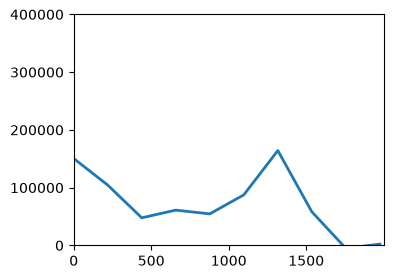

In [ ]:
# plot
data=np.array(vdos.totVDoS[0])
fig, ax = plt.subplots()
ax.plot(vdos.wavenumber, data, linewidth = 2.0)
ax.set(xlim=(0, 2000), xticks=np.arange(0,2000,500),
       ylim=(0, 400000.0), yticks=np.arange(0,400001,100000))
plt.show()